# L1.15 — Link gates

**Level 1 · Depth · 40 minutes**

**Goal.** You can turn a directed link off for a reason that is physical.

**Check at the end.** You can name a real system where A can see B while B cannot see A.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. A veto is not a probability of zero

Lesson L1.14 lost messages **statistically**: each link draws, and sometimes the draw fails. A gate
is different. It answers one question ahead of the draw:

> May this broadcast be offered on this directed link at all, right now?

```python
class LinkGate:
    def initial() -> object: ...
    def evolve(own, receivers, elapsed, rng) -> object: ...
    def admits(own, source, receiver) -> bool: ...
```

The contract is a **boolean**, not a multiplier, and that is load-bearing. A denied link consumes
**no randomness at all**: `admits` runs before the reception draw and skips it. Setting
`reception_prob = 0` instead would spend one draw for each suppressed link and shift every number
after it in the stream.

So the rule is:

- Something that **modulates** a probability belongs in `reception_prob`.
- Something that **forbids** a link belongs in a gate.

Gates compose. A link is offered only if **every** gate admits it. Radio failure and range are two
gates, not one class with two jobs.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN, ORANGE = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c", "#ff7f0e"

from opencdarr import M600, create_aircraft, generator, geo, root_seed_sequence
from opencdarr.cns import (
    Comm,
    GnssNavigation,
    RadioHealth,
    SurveillanceRange,
    TransceiverComm,
    radio_health,
)

FLEET = [create_aircraft(M600, id=name, lat=52.0, lon=4.0 + 0.01 * k, trk=0.0, gs=10.0,
                         pos_ci95=10.0, vel_ci95=1.0)
         for k, name in enumerate(("ALPHA", "BRAVO", "CHARLIE"))]
NAV = GnssNavigation()


def stream(seed: int):
    return generator(root_seed_sequence(seed))


print("the fleet:", [ac.id for ac in FLEET])
print("directed links:", [(a.id, b.id) for a in FLEET for b in FLEET if a.id != b.id])

the fleet: ['ALPHA', 'BRAVO', 'CHARLIE']
directed links: [('ALPHA', 'BRAVO'), ('ALPHA', 'CHARLIE'), ('BRAVO', 'ALPHA'), ('BRAVO', 'CHARLIE'), ('CHARLIE', 'ALPHA'), ('CHARLIE', 'BRAVO')]


## 2. A radio that fails

`RadioHealth` breaks transmitters and receivers separately. That separation is what makes the
failure **asymmetric**: an aircraft with a dead transmitter still hears everybody, and an aircraft
with a dead receiver still tells everybody where it is.

| Parameter | What it breaks |
| --- | --- |
| `tx_fail_rate`, `tx_recover_rate` | The transmitter. This aircraft stops being heard. |
| `rx_fail_rate`, `rx_recover_rate` | The receiver. This aircraft stops hearing. |

The rates are per **hour**, the same convention as lesson L1.13.

`TransceiverComm` is the named shorthand for `Comm(..., gates=(RadioHealth(...),))`. Use it when
radio failure is the only gate you need. Use the explicit form to add a second gate beside it.

In [2]:
radios = TransceiverComm(tx_fail_rate=120.0, tx_recover_rate=400.0,
                         rx_fail_rate=60.0, rx_recover_rate=400.0)

state = radios.initial_state()
rng = stream(2)
tx_down, rx_down, healths = [], [], []
for k in range(400):
    t = float(k)
    msgs = [NAV.measure(NAV.initial_state(), ac, t, rng) for ac in FLEET]
    state = radios.step(state, msgs, FLEET, t, rng)
    health = radio_health(state)
    healths.append(health)
    tx_down.append(frozenset(health.tx_down))
    rx_down.append(frozenset(health.rx_down))

print(f"{'aircraft':<10}{'transmitter down':>19}{'receiver down':>16}")
for ac in FLEET:
    print(f"{ac.id:<10}{np.mean([ac.id in s for s in tx_down]):>18.1%}"
          f"{np.mean([ac.id in s for s in rx_down]):>16.1%}")

both = np.mean([len(a) > 0 and len(b) > 0 for a, b in zip(tx_down, rx_down)])
print(f"\nticks with at least one of each broken: {both:.1%}")

aircraft     transmitter down   receiver down
ALPHA                  18.8%           25.2%
BRAVO                  25.0%           17.5%
CHARLIE                24.8%            9.8%

ticks with at least one of each broken: 20.8%


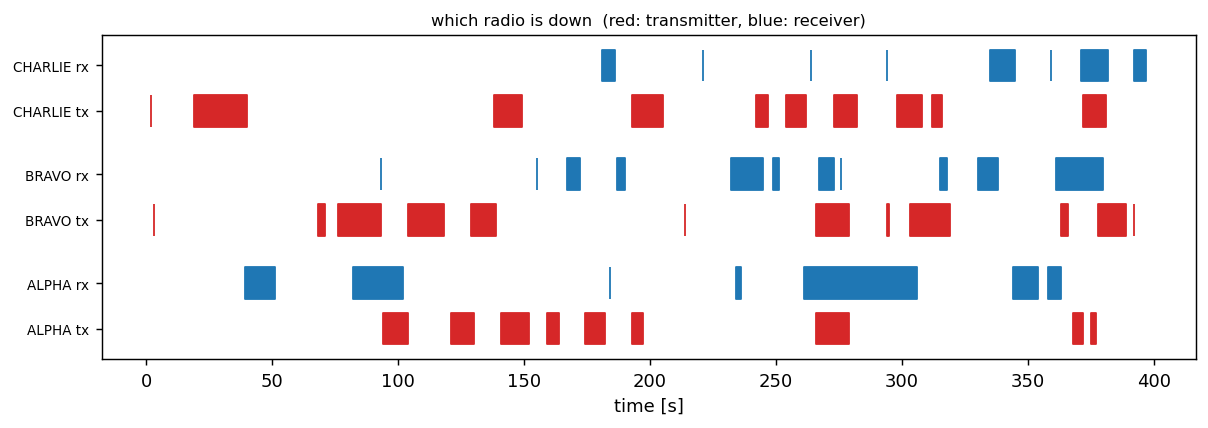

In [3]:
fig, ax = plt.subplots(figsize=(9.4, 3.4))
t = np.arange(len(tx_down))
row = 0
ticks, labels = [], []
for ac in FLEET:
    for kind, history, colour in (("tx", tx_down, RED), ("rx", rx_down, BLUE)):
        flags = np.array([ac.id in s for s in history])
        ax.fill_between(t, row, row + 0.7, where=flags, color=colour, step="mid")
        ticks.append(row + 0.35)
        labels.append(f"{ac.id} {kind}")
        row += 1
    row += 0.4
ax.set_yticks(ticks)
ax.set_yticklabels(labels, fontsize=7.5)
ax.set_xlabel("time [s]")
ax.set_title("which radio is down  (red: transmitter, blue: receiver)", fontsize=9)
fig.tight_layout()

## 3. Read the gate directly

`admits` is a pure function of the gate's state and two ids. Call it yourself to see which links are
open at one instant, without stepping the channel at all.

The result is a **matrix that is not symmetric**. That is the whole point of a directed link.

In [4]:
gate = RadioHealth(tx_fail_rate=120.0, tx_recover_rate=400.0,
                   rx_fail_rate=60.0, rx_recover_rate=400.0)

# pick a tick where something is actually broken, so the matrix has something to show
k = next(i for i, h in enumerate(healths) if h.tx_down and h.rx_down)
health = healths[k]

ids = [ac.id for ac in FLEET]
print(f"at t = {k} s:  tx down {sorted(health.tx_down) or 'none'},  "
      f"rx down {sorted(health.rx_down) or 'none'}\n")
header = "from / to"
print(f"{header:<10}" + "".join(f"{i:>10}" for i in ids))
for source in ids:
    cells = []
    for receiver in ids:
        cells.append("-" if source == receiver
                     else ("open" if gate.admits(health, source, receiver) else "VETOED"))
    print(f"{source:<10}" + "".join(f"{c:>10}" for c in cells))

at t = 39 s:  tx down ['CHARLIE'],  rx down ['ALPHA']

from / to      ALPHA     BRAVO   CHARLIE
ALPHA              -      open      open
BRAVO         VETOED         -      open
CHARLIE       VETOED    VETOED         -


## 4. A link that depends on geometry

`SurveillanceRange(max_range=...)` vetoes any link longer than `max_range`. It draws nothing: given
the geometry, it is deterministic.

Note how it is built. `evolve` takes a **snapshot** of where everyone is and keeps it in its own
state. `admits` is then a lookup by id. The tick's truth is read once, at a fixed point in the step,
rather than re-read for each of the N(N−1) links.

If you ask it about an aircraft it never saw, it **raises**. Admitting the link instead would
silently mean "always in range".

In [5]:
def approach(max_range: float, n: int = 60, closing: float = 40.0):
    """Two aircraft closing head-on. Returns (range [m], is the link open?) at each step."""
    gate = SurveillanceRange(max_range=max_range)
    own = gate.initial()
    rows = []
    for k in range(n):
        separation = 2400.0 - closing * k
        lat, lon = geo.forward(52.0, 4.0, 90.0, separation)
        pair = [create_aircraft(M600, id="ALPHA", lat=52.0, lon=4.0, trk=90.0, gs=16.0),
                create_aircraft(M600, id="BRAVO", lat=lat, lon=lon, trk=270.0, gs=16.0)]
        own = gate.evolve(own, pair, 1.0, stream(0))
        rows.append((separation, gate.admits(own, "ALPHA", "BRAVO")))
    return rows


for max_range in (500.0, 1000.0, 1500.0):
    rows = approach(max_range)
    first = next(r for r, ok in rows if ok)
    print(f"max_range {max_range:>7.0f} m   first contact at {first:.0f} m")

# ask about an aircraft the gate never saw
gate = SurveillanceRange(max_range=1000.0)
own = gate.evolve(gate.initial(), FLEET, 1.0, stream(0))
try:
    gate.admits(own, "ALPHA", "GHOST")
except ValueError as exc:
    print(f"\nasking about an unknown id: {str(exc)[:88]}...")

max_range     500 m   first contact at 480 m
max_range    1000 m   first contact at 1000 m
max_range    1500 m   first contact at 1480 m

asking about an unknown id: SurveillanceRange has no position for 'GHOST': it was not on the roster this channel was...


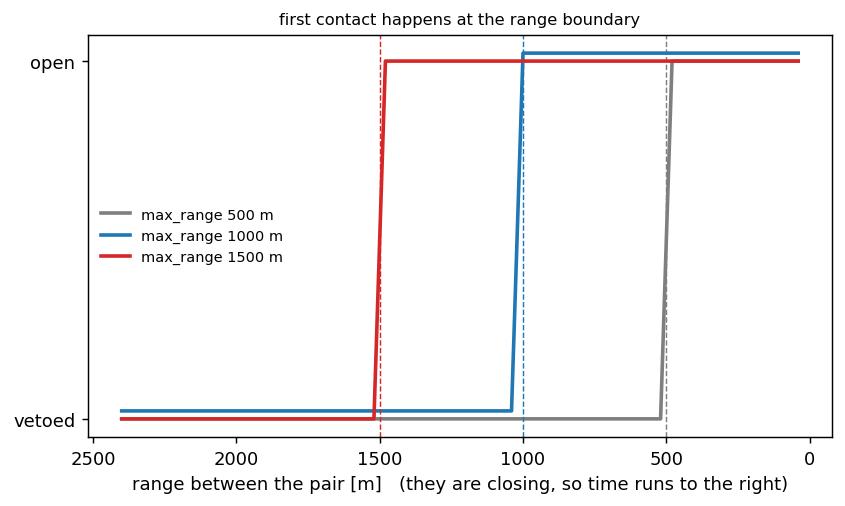

In [6]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
for max_range, colour in ((500.0, GREY), (1000.0, BLUE), (1500.0, RED)):
    rows = approach(max_range)
    ranges = np.array([r for r, _ in rows])
    open_link = np.array([ok for _, ok in rows])
    ax.plot(ranges, open_link.astype(float) * 0.9 + (0.02 if max_range == 1000.0 else 0.0),
            lw=2.0, color=colour, label=f"max_range {max_range:.0f} m")
    ax.axvline(max_range, ls="--", lw=0.8, color=colour)
ax.invert_xaxis()
ax.set_yticks([0, 0.9])
ax.set_yticklabels(["vetoed", "open"])
ax.set_xlabel("range between the pair [m]   (they are closing, so time runs to the right)")
ax.set_title("first contact happens at the range boundary", fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="center left")
fig.tight_layout()

## 5. Two gates at once

Pass a tuple. A link is offered only if **every** gate admits it, so the effects multiply without
either gate knowing about the other.

In [7]:
combined = Comm(
    reception_prob=0.95,
    latency=0.2,
    gates=(RadioHealth(tx_fail_rate=120.0, tx_recover_rate=400.0),
           SurveillanceRange(max_range=800.0)),
)

print(f"gates on this channel: {[type(g).__name__ for g in combined.gates]}")

state = combined.initial_state()
rng = stream(6)
delivered = 0
for k in range(200):
    t = float(k)
    pair = [create_aircraft(M600, id="ALPHA", lat=52.0, lon=4.0, trk=90.0, gs=16.0,
                            pos_ci95=10.0, vel_ci95=1.0),
            create_aircraft(M600, id="BRAVO", lat=52.0,
                            lon=geo.forward(52.0, 4.0, 90.0, max(2000.0 - 12.0 * k, 60.0))[1],
                            trk=270.0, gs=16.0, pos_ci95=10.0, vel_ci95=1.0)]
    msgs = [NAV.measure(NAV.initial_state(), ac, t, rng) for ac in pair]
    before = state.held.get(("BRAVO", "ALPHA"))
    state = combined.step(state, msgs, pair, t, rng)
    after = state.held.get(("BRAVO", "ALPHA"))
    if after is not None and (before is None or after.t_meas > before.t_meas):
        delivered += 1

print(f"messages BRAVO -> ALPHA delivered over 200 ticks: {delivered}")
print("(the range gate blocks the early ticks; the radio gate and the 0.95 draw take some of the rest)")

gates on this channel: ['RadioHealth', 'SurveillanceRange']
messages BRAVO -> ALPHA delivered over 200 ticks: 82
(the range gate blocks the early ticks; the radio gate and the 0.95 draw take some of the rest)


## Do it yourself

1. Set `tx_recover_rate=0.0`. A transmitter that fails never comes back. Read the timeline.
2. Build a gate of your own: a frozen dataclass with `initial`, `evolve` and `admits` that vetoes a
   link when the two aircraft are within 100 m of each other.
3. Put your gate and `SurveillanceRange` on the same channel, and check that both apply.
4. Compare `Comm(reception_prob=0.0)` with a gate that always vetoes. Count the draws each consumes.

## Check

1. Why is the gate contract a boolean instead of a multiplier?
2. A link is directed. Name a real system where A can see B while B cannot see A.
3. Why does `SurveillanceRange.evolve` take states, while `admits` takes ids?

## Next

`L1.16 — CNS: surveillance`. The messages have arrived. Next you find out what the separation logic
actually reads.